# Mesh refinement - 2D Circular Cylinder (Body Fitted Mesh)

### Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Domain Setup

In [ ]:
Diameter = 0.01 # Diameter of the cylinder

Lx = Diameter * 30 # Length of the domain in the x-direction (30 diameters long)
Ly = Diameter * 20 # Length of the domain in the y-direction (20 diameters wide)

cx = 5 * 0.01 # x-coordinate of the cylinder center (5 diameters from the inlet)
cy = Ly / 2 # y-coordinate of the cylinder center (centered in the y-direction)
R = Diameter / 2 # Radius of the cylinder


Re = 3900 # Reynolds number
Nu = 1.5 * 10**(-5) # Kinematic viscosity (arbitrary value for demonstration)
U = Re * Nu / Diameter # Inlet velocity calculated from Reynolds number
print("U:", U)
V = 0.0 # No velocity in the y-direction at the inlet
print("V:", V)

rho = 1.2

# check blockage
blockage = (Diameter / Ly) * 100
print("Blockage:", blockage,"%")

U: 5.8500000000000005
Blockage: 5.0 %


### Compute y1

In [3]:
target_y_plus = 1

print("Reynolds number:", Re)

# for external flow cf = 0.027 / R^(1/7) | for internal flow cf = 0.079 / Re^(1/5) for Re < 10e+5
C_f = 0.027 / Re**(1/7)
print("Friction coefficient:", C_f)

tau_w = C_f * 0.5 * rho * U**2
print("Wall shear stress:", tau_w)

u_tau = (tau_w / rho)**0.5
print("Friction velocity:", u_tau)

y1 = target_y_plus * Nu / u_tau
print("First cell height (y1):", y1)

Reynolds number: 3900
Friction coefficient: 0.008286183269793327
Wall shear stress: 0.17014434417030128
Friction velocity: 0.37654608413214324
First cell height (y1): 3.9835761496688345e-05


### Compute the normal grid

In [4]:
def exponential_grid_stretching(y1, r, N, H):
    y = np.zeros(N)
    y[0] = 0.0
    dy = y1
    for i in range(1, N):
        y[i] = y[i-1] + dy
        if y[i] > H:
            N = i # Update N to the actual number of points used
            break
        dy = dy * r
    return y, N


N = 100
r = 1.15
H = ((Diameter * 20 / 2) - R) / 2.5
y, N = exponential_grid_stretching(y1, r, N, H)
y = y[:N]  # Trim the array to the actual number of points used
print("Grid points (y):", y)
print("Number of grid points:", N)

Grid points (y): [0.00000000e+00 3.98357615e-05 8.56468872e-05 1.38329682e-04
 1.98914896e-04 2.68587891e-04 3.48711837e-04 4.40854374e-04
 5.46818291e-04 6.68676796e-04 8.08814077e-04 9.69971950e-04
 1.15530350e-03 1.36843479e-03 1.61353577e-03 1.89540190e-03
 2.21954795e-03 2.59231590e-03 3.02099904e-03 3.51398466e-03
 4.08091812e-03 4.73289160e-03 5.48266111e-03 6.34489603e-03
 7.33646620e-03 8.47677189e-03 9.78812344e-03 1.12961777e-02
 1.30304401e-02 1.50248419e-02 1.73184040e-02 1.99560003e-02
 2.29892361e-02 2.64774573e-02 3.04889117e-02 3.51020842e-02]
Number of grid points: 36


### Aspect Ratio Constraint

In [5]:
# azimuthal resolution
N_deta = 240

ar_limit = 100
d_deta_max = ar_limit * y1 / R
N_deta_min = 2 * np.pi / d_deta_max

if N_deta > N_deta_min:
    print("The resolution near a cylinder is above the AR limit constraint N deta min", N_deta,">", N_deta_min)
else:
    print("W: The resolution near a cylinder is below the AR limit constraint N deta min", N_deta,"<", N_deta_min)

The resolution near a cylinder is above the AR limit constraint N deta min 240 > 7.886362744316968


### Create Body Fitted Mesh

In [6]:
r_1d = R + y
deta_1d = np.linspace(0, 2*np.pi, N_deta)
r_grid, deta_grid = np.meshgrid(r_1d, deta_1d)

# Transform Polar (r, θ) → Cartesian (x, y) Mesh
x_ogrid = r_grid * np.cos(deta_grid)
y_ogrid = r_grid * np.sin(deta_grid)

print("O-grid X shape:", x_ogrid.shape)
print("O-grid Y shape:", y_ogrid.shape)
print("Inner boundary radius check (should equal R):", np.min(r_grid))

O-grid X shape: (240, 36)
O-grid Y shape: (240, 36)
Inner boundary radius check (should equal R): 0.005


### Visualize the O - grid Mesh

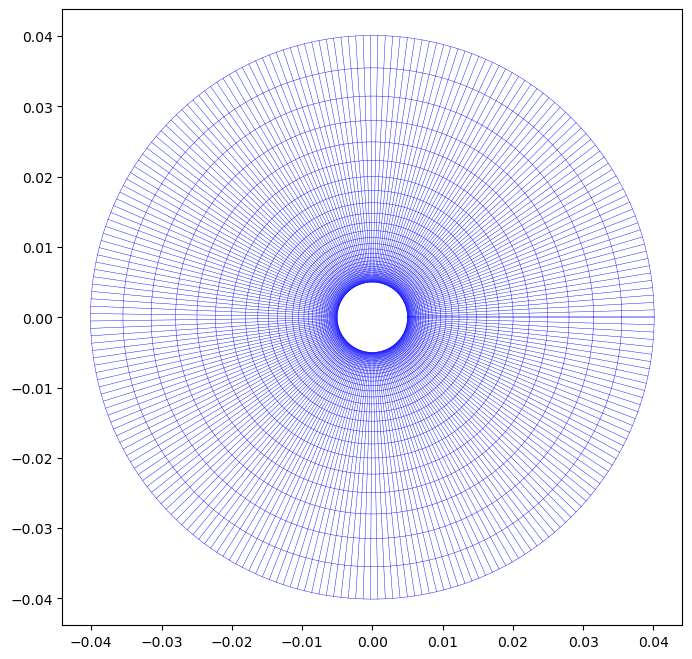

In [7]:
plt.figure(figsize=(8, 8))
plt.plot(x_ogrid.T, y_ogrid.T, 'b-', linewidth=0.3)
plt.plot(x_ogrid, y_ogrid,'b-', linewidth=0.3)
plt.axis('equal')
plt.show()

### Wake refinement

In [8]:
dy_outer = y[-1] - y[-2]
ds_outer = r_1d[-1] * (2*np.pi/N_deta)

dx_wake_target = Diameter / 20   # ~20 cells per D, typical wake-resolving guideline
print(dx_wake_target)

# dx_wake = np.maximum(dy_outer, ds_outer)
dx_wake = dx_wake_target

x_wake_start = cx + r_1d[-1]
x_wake_end = x_wake_start + 15 * Diameter
Nx_wake = int(np.ceil((x_wake_end - x_wake_start) / dx_wake)) + 1
x_wake = np.linspace(x_wake_start, x_wake_end, Nx_wake)

print(Nx_wake)

r_trans = 0.85  # try this first
N_trans = int(np.ceil(np.log(dx_wake_target / dy_outer) / np.log(r_trans)))
print(N_trans)

def exponential_grid_shrinking(d_start, r_trans, N, d_target):
    d = np.zeros(N)
    d[0] = d_start
    for i in range(1, N):
        d[i] = d[i-1] * r_trans
        if d[i] < d_target:
            N = i + 1
            break
    return d[:N], N

# 1. transition zone (right after O-grid edge)
d_trans, N_trans_actual = exponential_grid_shrinking(dy_outer, r_trans, N_trans + 5, dx_wake_target)
x_trans = (cx + r_1d[-1]) + np.cumsum(d_trans)

# 2. wake box starts where transition ends
x_wake_start = x_trans[-1]
x_wake_end = x_wake_start + 15 * Diameter
Nx_wake = int(np.ceil((x_wake_end - x_wake_start) / dx_wake_target)) + 1
x_wake = np.linspace(x_wake_start, x_wake_end, Nx_wake)

x_downstream = np.concatenate([x_trans, x_wake[1:]])
print(np.all(np.diff(x_downstream) > 0))  # sanity check: must be True


0.0005
301
14
True


### Availible Distance from the Inlet to O grid edge

In [9]:
H_upstream = (cx - r_1d[-1])  # available distance, inlet to O-grid edge
y_up, N_up = exponential_grid_stretching(dy_outer, 1.15, 100, H_upstream)
y_up = y_up[:N_up]
x_upstream = (cx - r_1d[-1]) - y_up[::-1]

print(x_upstream[0])
print(x_upstream[-1])
print(cx - r_1d[-1])
print(np.all(np.diff(x_upstream) > 0))

print("y_up:", y_up)
print("N_up:", N_up)


0.0052847433101150115
0.009897915821637654
0.009897915821637654
True
y_up: [0.         0.00461317]
N_up: 2


### Downstream of the wake box → outlet

In [10]:
H_downstream = Lx - x_downstream[-1]
y_down, N_down = exponential_grid_stretching(dx_wake_target, 1.15, 100, H_downstream)
y_down = y_down[:N_down]   # don't forget this trim again
x_far_downstream = x_downstream[-1] + y_down

### Lateral (top and bottom), using the O-grid/wake box half-height as the fine edge

In [11]:
H_lateral = (Ly - cy) - r_1d[-1]   # distance from wake-box top edge to the top wall
y_lat, N_lat = exponential_grid_stretching(dy_outer, 1.15, 100, H_lateral)
y_lat = y_lat[:N_lat]
y_top = (cy + r_1d[-1]) + y_lat
y_bottom = (cy - r_1d[-1]) - y_lat   # mirror for the bottom wall

print(x_downstream[-1], x_far_downstream[0])

x_full = np.concatenate([x_upstream, x_downstream, x_far_downstream[1:]])
print(np.all(np.diff(x_full) > 0))
print("x_full shape:", x_full.shape)
print("x_full[0], x_full[-1]:", x_full[0], x_full[-1])

0.26817003370635717 0.26817003370635717
True
x_full shape: (334,)
x_full[0], x_full[-1]: 0.0052847433101150115 0.2960287699514794


### Visualize the Domain after meshing

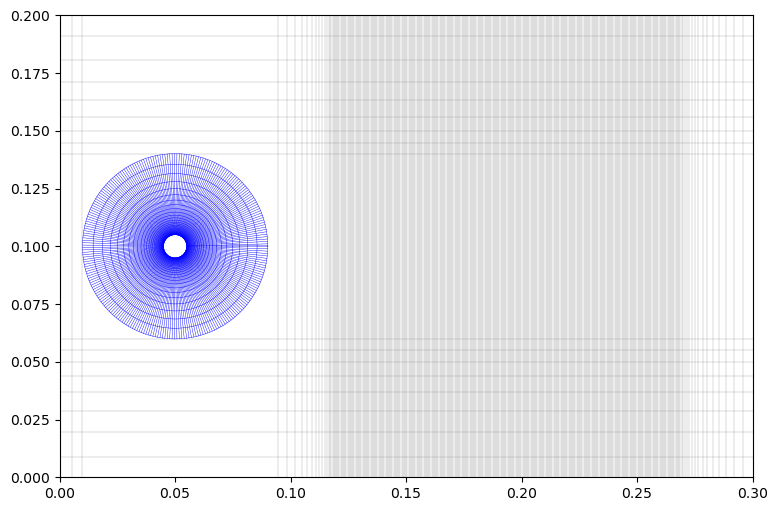

In [12]:
y_full = np.concatenate([y_bottom[::-1], y_top])  # already absolute coords; just reverse for ascending order

plt.figure(figsize=(10, 6))
plt.plot((x_ogrid + cx).T, (y_ogrid + cy).T, 'b-', linewidth=0.3)
plt.plot(x_ogrid + cx, y_ogrid + cy, 'b-', linewidth=0.3)

for xv in x_full:
    plt.axvline(xv, color='gray', linewidth=0.2)
for yv in y_full:
    plt.axhline(yv, color='gray', linewidth=0.2)

plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.gca().set_aspect('equal')
plt.show()